<a href="https://colab.research.google.com/github/Joaoplims/NLP-HandsOn/blob/main/HO00/HO00_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HO00 - João

Optei por ler um documento de texto que descreve a lei conhecida como **ECA Digital**. Por se tratar de um texto jurídico, o pipeline escolhido foi:

* **Case Folding:** Transformei todo o vocabulário em palavras minúsculas. Analisei previamente e notei poucas siglas, então o case folding seria útil para reduzir o vocabulário sem perder a semântica.

* **Remoção de pontuação:** Apliquei um regex para identificar padrões como "Art.", visto que, no meu entendimento, estes padrões fazem parte de um jargão técnico bem específico da área. Após separar estes jargões, removi toda a pontuação. Neste caso, talvez não tenha sido uma boa ideia, visto que o rigor e o formalismo do texto podem fazer com que o texto final perca sentido semântico.

* **Lematização:** Optei por usar a lematização ao invés do stemming. A ideia aqui é que, como o lema se assemelha à escrita do dicionário, um pós-processamento poderia ser utilizado, caso necessário, para reobter o significado real de um token lematizado.

* **Stop Words:** Embora acredite que a remoção de stop words possa prejudicar severamente o entendimento do texto no meu exemplo, decidi fazer um teste para entender se realmente remover stop words reduziria drasticamente o tamanho do vocabulário.

Para cada etapa, calculei o índice de TTR (Type-Token Ratio) para entender se, ao final do processamento, ainda teria um conjunto de dados rico semanticamente. O resultado final mostra uma evolução significativa após a filtragem das stop words.

Como este projeto não tinha um objetivo específico (por exemplo, aplicar alguma técnica de análise textual), é inconclusivo dizer se meu pipeline atende a algum objetivo prático. Mas o objetivo deste exercício — reduzir ao máximo o tamanho do vocabulário mantendo o contexto semântico — foi atendido, e o resultado pode ser visualizado na nuvem de palavras gerada, que destaca palavras importantes que representam um contexto relevante do texto.

In [2]:
pip install pymupdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 59.4 MB/s eta 0:00:00


Tentando baixar o arquivo do GitHub: https://raw.githubusercontent.com/Joaoplims/NLP-HandsOn/d7e89e1118fe43149169c385f49b3d1e9c05aa31/HO00/L15211%20-%20eca%20digital.pdf
Arquivo baixado e salvo localmente em: /tmp/eca_digital.pdf

Lendo arquivo: eca_digital.pdf

Análise concluída!
Total de palavras: 7128
Tamanho do vocabulário: 1469


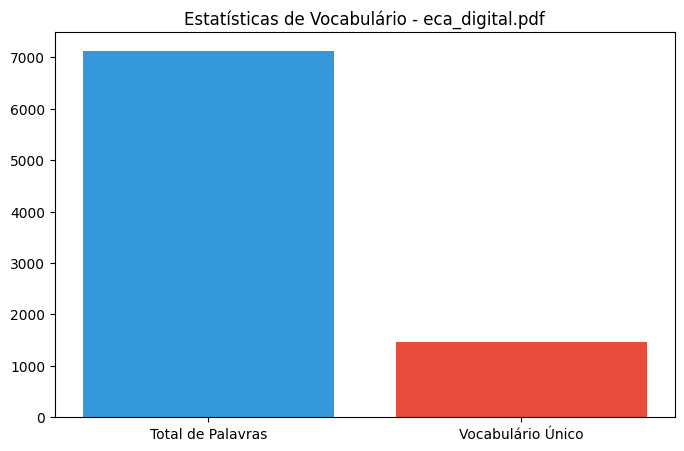

In [7]:
import fitz  # PyMuPDF
import os
import re
import matplotlib.pyplot as plt
import requests

# --- Configuração para ler PDF do GitHub ---
# Corrigido para o link RAW para evitar baixar o HTML do GitHub
github_pdf_url = "https://raw.githubusercontent.com/Joaoplims/NLP-HandsOn/d7e89e1118fe43149169c385f49b3d1e9c05aa31/HO00/L15211%20-%20eca%20digital.pdf"
#github_pdf_url = "https://raw.githubusercontent.com/Joaoplims/NLP-HandsOn/c7225235c6fb1e0933c25e553d6dd40f7c3e2bb1/HO00/L15211%20-%20eca%20digital.pdf"
local_pdf_path = "/tmp/eca_digital.pdf"

print(f"Tentando baixar o arquivo do GitHub: {github_pdf_url}")

try:
    # 1. Baixar o arquivo do GitHub
    response = requests.get(github_pdf_url)
    response.raise_for_status()

    with open(local_pdf_path, 'wb') as f:
        f.write(response.content)
    print(f"Arquivo baixado e salvo localmente em: {local_pdf_path}\n")

    # 2. Abrir e processar o PDF com PyMuPDF
    doc = fitz.open(local_pdf_path)
    processed_file_name = os.path.basename(local_pdf_path)
    print(f"Lendo arquivo: {processed_file_name}\n")

    full_text = ""
    for page_num in range(len(doc)):
        page = doc.load_page(page_num)
        page_text = page.get_text()
        full_text += page_text

    doc.close()

    # Tokenização simples
    words = re.findall(r'\w+', full_text.lower())
    total_words = len(words)
    vocab_size = len(set(words))

    print(f"Análise concluída!")
    print(f"Total de palavras: {total_words}")
    print(f"Tamanho do vocabulário: {vocab_size}")

    # Gerar o gráfico
    labels = ['Total de Palavras', 'Vocabulário Único']
    values = [total_words, vocab_size]
    plt.figure(figsize=(8, 5))
    bars = plt.bar(labels, values, color=['#3498db', '#e74c3c'])
    plt.title(f'Estatísticas de Vocabulário - {processed_file_name}')
    plt.show()

except Exception as e:
    print(f"Erro ao processar o PDF: {e}")

In [8]:
import re

# Texto original em minúsculas para processamento
text_to_process = full_text.lower()

# 1. Definimos uma regex que captura estruturas como 'art. 1º', 'art. 22', '§ 1º', etc.
# O padrão busca: (art\.) ou (§) seguido de espaço opcional, números e possivelmente º ou ª
structural_pattern = r'(art\.\s?\d+[ºª]?|§\s?\d+[ºª]?)'

# 2. Tokenização customizada:
# Primeiro, isolamos o que é estrutura de lei, e o que sobrar tratamos como palavras comuns
# Usamos o finditer para capturar tudo
tokens_final = []

# Vamos usar uma abordagem de regex que mantém os padrões legais intactos
# e remove pontuação puramente gramatical (., ! ? : ;)

def clean_punctuation(text):
    # Esta regex remove pontuação comum mas ignora o que combine com o padrão de lei
    # Para simplificar, vamos capturar as palavras e as estruturas legais separadamente
    pattern = r'art\.\s?\d+[ºª]?|§\s?\d+[ºª]?|\w+[ºª]?|\d+'
    return re.findall(pattern, text)

tokens_sanitized = clean_punctuation(text_to_process)

print(f"Exemplo de tokens preservando estrutura (primeiros 50):\n{tokens_sanitized[:50]}")

# Verificando se encontramos algum 'art.' específico
art_examples = [t for t in tokens_sanitized if 'art.' in t][:5]
print(f"\nExemplos de Artigos preservados: {art_examples}")

Exemplo de tokens preservando estrutura (primeiros 50):
['presidência', 'da', 'república', 'casa', 'civil', 'secretaria', 'especial', 'para', 'assuntos', 'jurídicos', 'lei', 'nº', '15', '211', 'de', '17', 'de', 'setembro', 'de', '2025', 'mensagem', 'de', 'veto', 'vigência', 'regulamento', 'regulamento', 'dispõe', 'sobre', 'a', 'proteção', 'de', 'crianças', 'e', 'adolescentes', 'em', 'ambientes', 'digitais', 'estatuto', 'digital', 'da', 'criança', 'e', 'do', 'adolescente', 'o', 'presidente', 'da', 'república', 'faço', 'saber']

Exemplos de Artigos preservados: ['art. 1º', 'art. 2º', 'art. 2º', 'art. 5º', 'art. 3º']


In [11]:
!python -m spacy download pt_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 79.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [9]:
# 1. Case Folding: Convertendo todo o texto para minúsculas
text_lower = full_text.lower()

# 2. Tokenização simples para visualizar o resultado do Case Folding
# (Removendo pontuação básica para facilitar a visualização inicial)
import re
tokens_case_folded = re.findall(r'\w+', text_lower)

print(f"Exemplo de tokens após Case Folding (primeiros 20):\n{tokens_case_folded[:20]}")
print(f"\nTotal de tokens processados: {len(tokens_case_folded)}")

Exemplo de tokens após Case Folding (primeiros 20):
['presidência', 'da', 'república', 'casa', 'civil', 'secretaria', 'especial', 'para', 'assuntos', 'jurídicos', 'lei', 'nº', '15', '211', 'de', '17', 'de', 'setembro', 'de', '2025']

Total de tokens processados: 7128


In [12]:
import spacy
import pt_core_news_sm

# Carregando o modelo
nlp = pt_core_news_sm.load()

# Unindo os tokens sanitizados para processamento
text_for_lemmatization = " ".join(tokens_sanitized)

# Processando o texto
doc_spacy = nlp(text_for_lemmatization)

# Extraindo os lemas
tokens_lemmatized = [token.lemma_ for token in doc_spacy]

# --- Cálculo do TTR (Type-Token Ratio) ---
# TTR = Vocabulário Único / Total de Tokens
total_lemmas = len(tokens_lemmatized)
unique_lemmas = len(set(tokens_lemmatized))
ttr_lemmatized = unique_lemmas / total_lemmas if total_lemmas > 0 else 0

print(f"--- Estatísticas de Lematização ---")
print(f"Total de lemas: {total_lemmas}")
print(f"Lemas únicos (Vocabulário): {unique_lemmas}")
print(f"TTR (Type-Token Ratio): {ttr_lemmatized:.4f}")

print(f"\nComparação de Lemas (primeiros 10):")
for original, lemma in zip(tokens_sanitized[:10], tokens_lemmatized[:10]):
    print(f"{original} -> {lemma}")

--- Estatísticas de Lematização ---
Total de lemas: 7186
Lemas únicos (Vocabulário): 1206
TTR (Type-Token Ratio): 0.1678

Comparação de Lemas (primeiros 10):
presidência -> presidência
da -> de o
república -> república
casa -> casa
civil -> civil
secretaria -> secretaria
especial -> especial
para -> para
assuntos -> assunto
jurídicos -> jurídico


In [13]:
# 1. Filtrando stopwords dos tokens lematizados
# O spaCy já possui uma lista interna de stopwords para o português
tokens_final_no_stop = [token for token in tokens_lemmatized if not nlp.vocab[token].is_stop]

# 2. Cálculo do TTR após remoção de stopwords
total_tokens_final = len(tokens_final_no_stop)
unique_tokens_final = len(set(tokens_final_no_stop))
ttr_final = unique_tokens_final / total_tokens_final if total_tokens_final > 0 else 0

print(f"--- Estatísticas após Remoção de Stopwords ---")
print(f"Total de tokens restantes: {total_tokens_final}")
print(f"Tokens únicos: {unique_tokens_final}")
print(f"Novo TTR: {ttr_final:.4f}")

print(f"\nComparação com o TTR anterior (Lematizado): {ttr_lemmatized:.4f}")
print(f"Aumento na densidade lexical: {((ttr_final/ttr_lemmatized)-1)*100:.2f}%")

# Exemplo dos tokens resultantes
print(f"\nExemplo de tokens finais (primeiros 20):\n{tokens_final_no_stop[:20]}")

--- Estatísticas após Remoção de Stopwords ---
Total de tokens restantes: 4663
Tokens únicos: 1117
Novo TTR: 0.2395

Comparação com o TTR anterior (Lematizado): 0.1678
Aumento na densidade lexical: 42.73%

Exemplo de tokens finais (primeiros 20):
['presidência', 'de o', 'república', 'casa', 'civil', 'secretaria', 'especial', 'assunto', 'jurídico', 'Lei', 'nº', '15', '211', '17', 'setembro', '2025', 'mensagem', 'veto', 'vigência', 'regulamento']


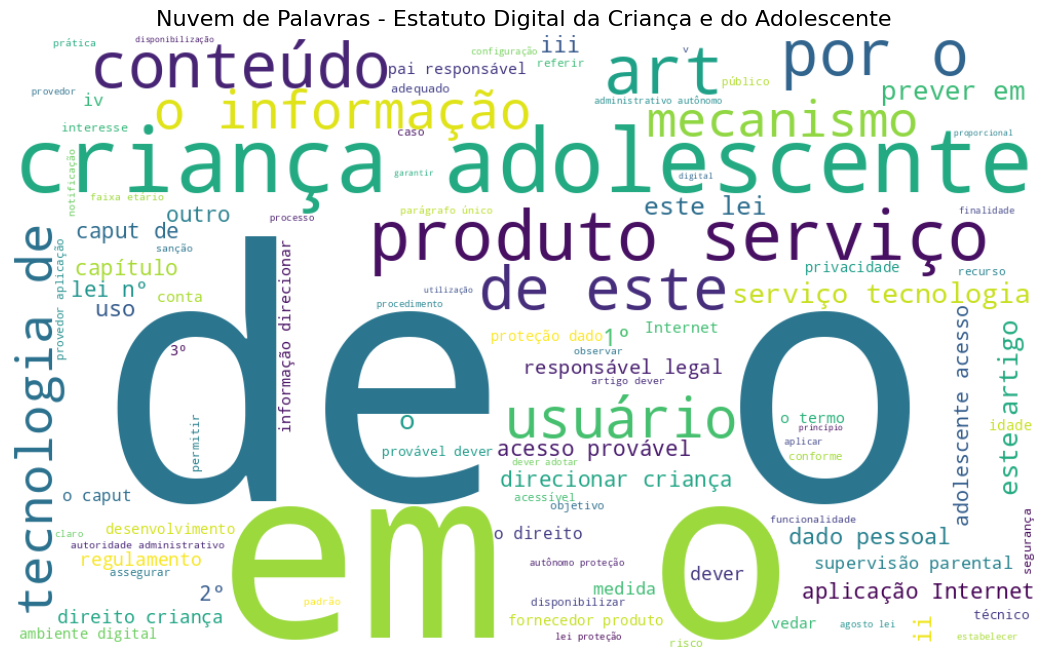

In [14]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 1. Preparar o texto para a nuvem (unindo os tokens finais)
text_for_cloud = " ".join(tokens_final_no_stop)

# 2. Configurar a nuvem de palavras
wordcloud = WordCloud(
    width=1000,
    height=600,
    background_color='white',
    colormap='viridis',
    max_words=100
).generate(text_for_cloud)

# 3. Exibir o gráfico
plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Nuvem de Palavras - Estatuto Digital da Criança e do Adolescente', fontsize=16)
plt.show()

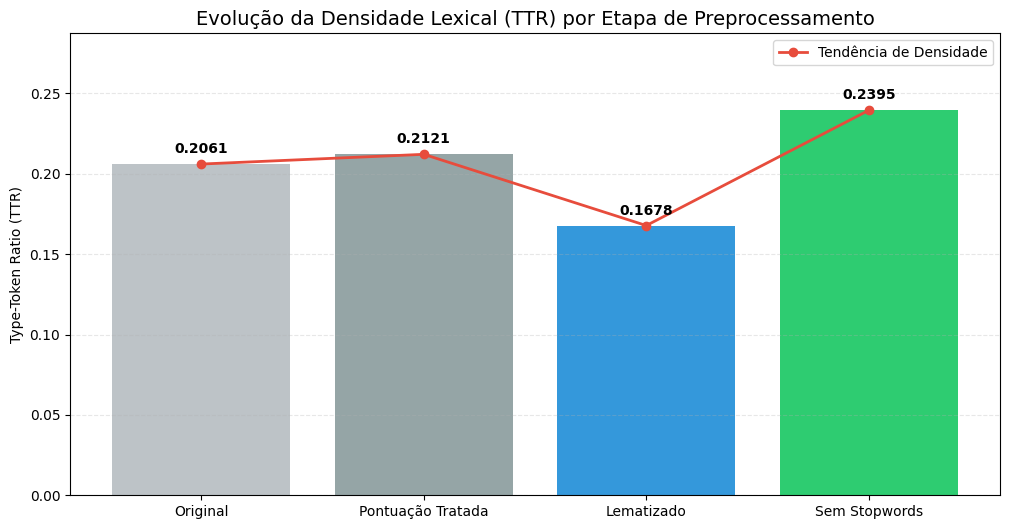

In [15]:
import matplotlib.pyplot as plt

# Calculando TTRs que faltavam para a comparação
ttr_original = len(set(tokens_case_folded)) / len(tokens_case_folded)
ttr_sanitized = len(set(tokens_sanitized)) / len(tokens_sanitized)

# Dados para o gráfico
etapas = ['Original', 'Pontuação Tratada', 'Lematizado', 'Sem Stopwords']
valores_ttr = [ttr_original, ttr_sanitized, ttr_lemmatized, ttr_final]

plt.figure(figsize=(12, 6))
colors = ['#bdc3c7', '#95a5a6', '#3498db', '#2ecc71']
bars = plt.bar(etapas, valores_ttr, color=colors)

# Adicionando rótulos de dados
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f'{yval:.4f}', ha='center', va='bottom', fontweight='bold')

plt.title('Evolução da Densidade Lexical (TTR) por Etapa de Preprocessamento', fontsize=14)
plt.ylabel('Type-Token Ratio (TTR)')
plt.ylim(0, max(valores_ttr) * 1.2)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Adicionar uma linha de tendência
plt.plot(etapas, valores_ttr, color='#e74c3c', marker='o', linestyle='-', linewidth=2, label='Tendência de Densidade')

plt.legend()
plt.show()